In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
import kagglehub



In [2]:

path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Veri seti yolu:", path)


Veri seti yolu: /home/sero/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2


In [5]:
# GIRIS VE DOGRULAMA ICIN BOYUT AYARLAMALARI TESTİ 
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        transforms.RandomRotation(15),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomVerticalFlip()
    ]),
    'val': transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        transforms.RandomRotation(15),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomVerticalFlip(),
    ]),
}

In [6]:
from torch.utils.data import Dataset
from PIL import Image
import os
import numpy as np

class BrainTumorDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        # Import'lar burada da gerekli
        from skimage import io as skio
        
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        
        for cls in self.classes:
            cls_path = os.path.join(root_dir, cls)
            if not os.path.isdir(cls_path):
                continue
            for fname in os.listdir(cls_path):
                if fname.lower().endswith(('.jpg', '.png', '.jpeg')):
                    self.samples.append((os.path.join(cls_path, fname), self.class_to_idx[cls]))

    def preprocess(self, img_array):
        from skimage import exposure, filters
        from skimage.morphology import disk
        from skimage import util
        
        hist = exposure.equalize_hist(img_array)
        img_ubyte = util.img_as_ubyte(img_array)
        meaned = filters.rank.mean(img_ubyte, disk(2))
        laplacian = filters.laplace(img_array)
        result = 255 + ((meaned * hist) * (hist**5) - meaned) + laplacian
        result = np.clip(result, 0, 255).astype(np.uint8)
        return np.stack([result, result, result], axis=-1)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        from skimage import io as skio
        
        path, label = self.samples[idx]
        img = skio.imread(path, as_gray=True)
        img = self.preprocess(img)
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img, label

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import os

data_dir = "/home/sero/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2"

# Transformlar
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

# Dataset yükleme
image_datasets = {
    'train': BrainTumorDataset(
        os.path.join(data_dir, 'Training'), 
        transform=data_transforms['train']
    ),
    'val': BrainTumorDataset(
        os.path.join(data_dir, 'Testing'),
        transform=data_transforms['val']
    ),
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=2)
    for x in ['train', 'val']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names   = image_datasets['train'].classes
device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device}")
print(f"Sınıflar: {class_names}")
print(f"Eğitim: {dataset_sizes['train']} | Doğrulama: {dataset_sizes['val']}")

Device: cuda
Sınıflar: ['glioma', 'meningioma', 'notumor', 'pituitary']
Eğitim: 5600 | Doğrulama: 1600


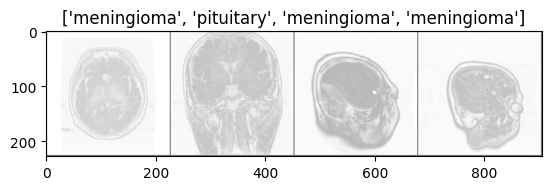

In [8]:
import torchvision
import numpy as np 
import matplotlib.pyplot as plt 
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.show()

inputs, classes = next(iter(dataloaders['train']))
out = torchvision.utils.make_grid(inputs[:4])
imshow(out, title=[class_names[x] for x in classes[:4]])

In [10]:
def initialize_resnet(num_classes):
    model = models.resnext50_32x4d(weights='IMAGENET1K_V1')
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model.to(device)

try:
    model = initialize_resnet(num_classes=len(class_names))
    print("ResNet50 modeli başarıyla yüklendi.")
except NameError:
    print("Hata")

ResNet50 modeli başarıyla yüklendi.


In [ ]:
def train_model(model, criterion, optimizer, num_epochs=10):

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

    return model

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Eğitim için kayıp fonksiyonu ve optimizer hazır.")

Eğitim için kayıp fonksiyonu ve optimizer hazır.


In [ ]:
import time
import copy
import torch

def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val':
   
                if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    scheduler.step(epoch_loss)
                else:
                    scheduler.step()
                # ----------------------
                
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
        print()

    time_elapsed = time.time() - since
    print(f'Eğitim tamamlandı: {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'En iyi doğrulama başarısı: {best_acc:4f}')
    model.load_state_dict(best_model_wts)
    return model

if 'scheduler' not in globals():
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

model_ft = train_model(model, criterion, optimizer, scheduler, num_epochs=15)

In [ ]:
### MODEL EĞİTİMİ BİTTİKTEN SONRA YANLIŞLIKLA TEKRAR ÇALIŞTIRDIK BU YÜZDEN BURADAKİ MATRİSİMİZ BOZULDU MODELİN EN İYİ HALİNİ KAYDETMİŞTİK

Test Doğruluğu: %28.94

Sınıflandırma Raporu:
              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00       400
  meningioma       0.86      0.16      0.27       400
     notumor       0.26      1.00      0.42       400
   pituitary       0.00      0.00      0.00       400

    accuracy                           0.29      1600
   macro avg       0.28      0.29      0.17      1600
weighted avg       0.28      0.29      0.17      1600



/home/sero/miniconda3/envs/medikal_egitim/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sero/miniconda3/envs/medikal_egitim/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sero/miniconda3/envs/medikal_egitim/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

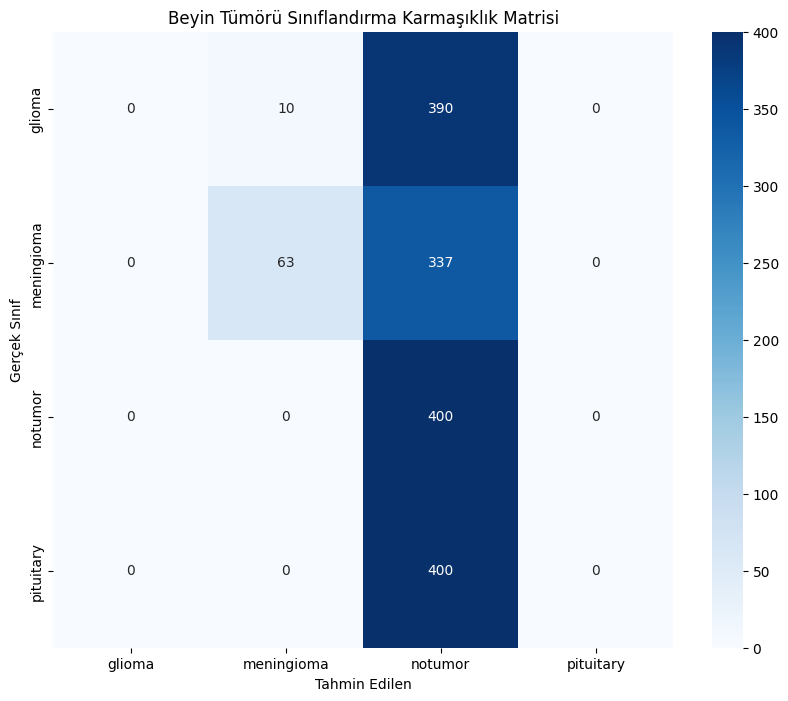

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import torch

def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(f"Test Doğruluğu: %{accuracy_score(all_labels, all_preds)*100:.2f}")
    print("\nSınıflandırma Raporu:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Tahmin Edilen')
    plt.ylabel('Gerçek Sınıf')
    plt.title('Beyin Tümörü Sınıflandırma Karmaşıklık Matrisi')
    plt.show()

# En iyi sonuç veren model ile tekrar değerlendir
evaluate_model(model_ft, dataloaders['val'])

In [ ]:
from PIL import Image
import torch.nn.functional as F
import glob


def predict_image(model, class_names, image_path):
    # Görüntüyü aç
    img = Image.open(image_path).convert('RGB')
    plt.imshow(img)
    plt.title("Girdi Görüntüsü")
    plt.axis('off')
    plt.show()

    # Transform uygula
    img_t = data_transforms['val'](img)
    batch_t = torch.unsqueeze(img_t, 0).to(device)

    # Tahmin yap
    model.eval()
    with torch.no_grad():
        out = model(batch_t)
        probabilities = F.softmax(out, dim=1)
        conf, preds = torch.max(probabilities, 1)

    result = class_names[preds[0]]
    confidence = conf[0].item() * 100
    print(f"Tahmin: {result.upper()}")
    print(f"Güven Oranı: %{confidence:.2f}")
for path in glob.glob("/home/sero/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training/meningioma/*.jpg"):
    print(f"\n--- {os.path.basename(path)} ---")
    predict_image(model_ft, class_names, path)
#predict_image(model_ft, class_names, "/home/sero/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Testing/meningioma/Tr-aug-me_90.jpg")

In [ ]:
import torch

model_save_path = 'brain_tumor_resnet50_model.pth'

if 'model_ft' in locals() or 'model_ft' in globals():
    torch.save(model_ft.state_dict(), model_save_path)
    print(f"Model '{model_save_path}' konumuna kaydedildi.")
else:
    print("Hata: 'model_ft' tanımlanmamış. Lütfen modeli eğittiğiniz 1cf00e31 hücresini çalıştırdığınızdan emin olun.")
